In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


Dataset shape: (672, 54)
Target distribution:
 target
0    412
1    260
Name: count, dtype: int64
Feature matrix shape: (672, 53)
Top 15 features by F-value:
 7. In the last two weeks, trouble concentrating on things, such as reading the newspaper or watching television._num            206.816020
6. In the last two weeks, feeling bad about yourself-or that you are a failure or have let yourself or your family down._num    200.202873
8. In the last  two weeks, moving or speaking so slowly or the opposite-moving around a lot more than usual._num                191.363426
9. In the last two weeks, thoughts that you would be better off dead, or of hurting yourself in some way._num                   178.126011
5. In the last two weeks, poor appetite or over-eating._num                                                                     140.805905
1. In the last two weeks, I am feeling nervous, anxious, or on edge._num                                                         96.280490
2. In t

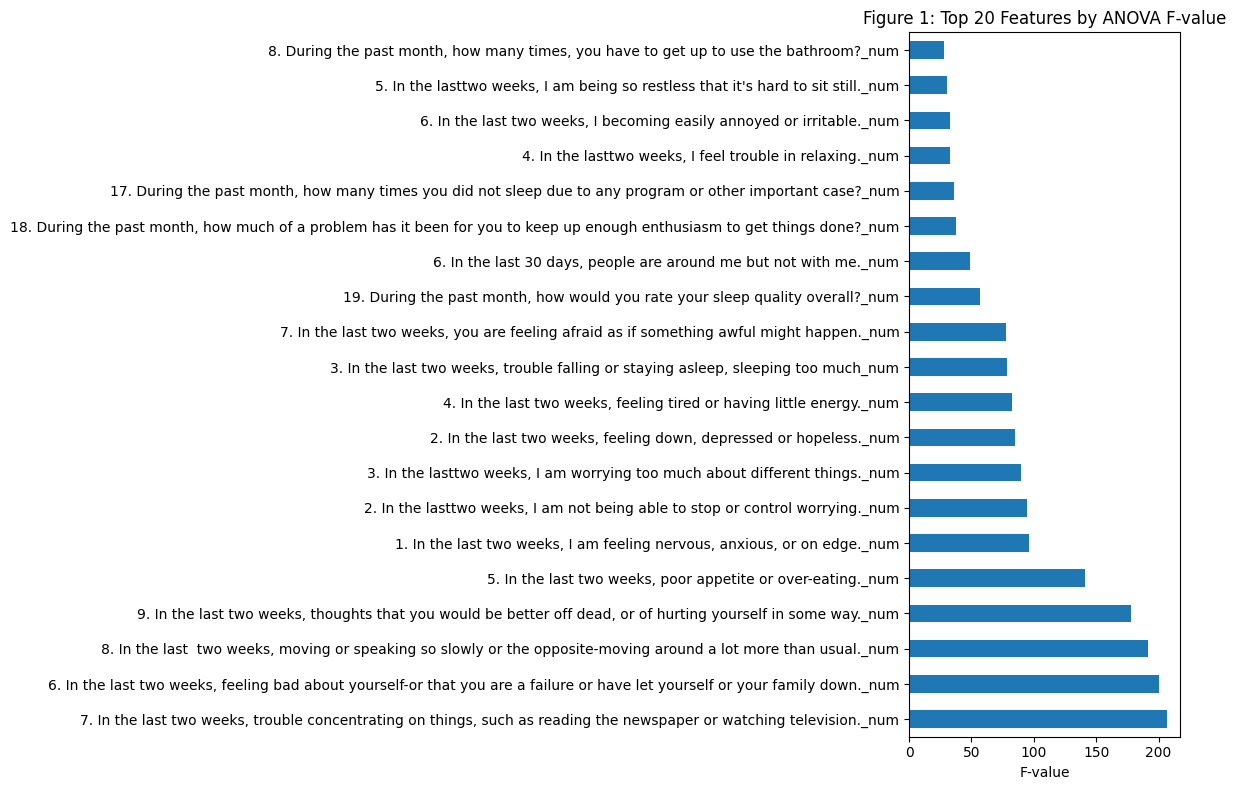

Optimal number of features selected: 10
Selected features: ['1. In the last two weeks, little interest or pleasure in doing things._num', '2. In the last two weeks, feeling down, depressed or hopeless._num', '3. In the last two weeks, trouble falling or staying asleep, sleeping too much_num', '4. In the last two weeks, feeling tired or having little energy._num', '5. In the last two weeks, poor appetite or over-eating._num', '6. In the last two weeks, feeling bad about yourself-or that you are a failure or have let yourself or your family down._num', '7. In the last two weeks, trouble concentrating on things, such as reading the newspaper or watching television._num', '8. In the last  two weeks, moving or speaking so slowly or the opposite-moving around a lot more than usual._num', '9. In the last two weeks, thoughts that you would be better off dead, or of hurting yourself in some way._num', '3. In the lasttwo weeks, I am worrying too much about different things._num']


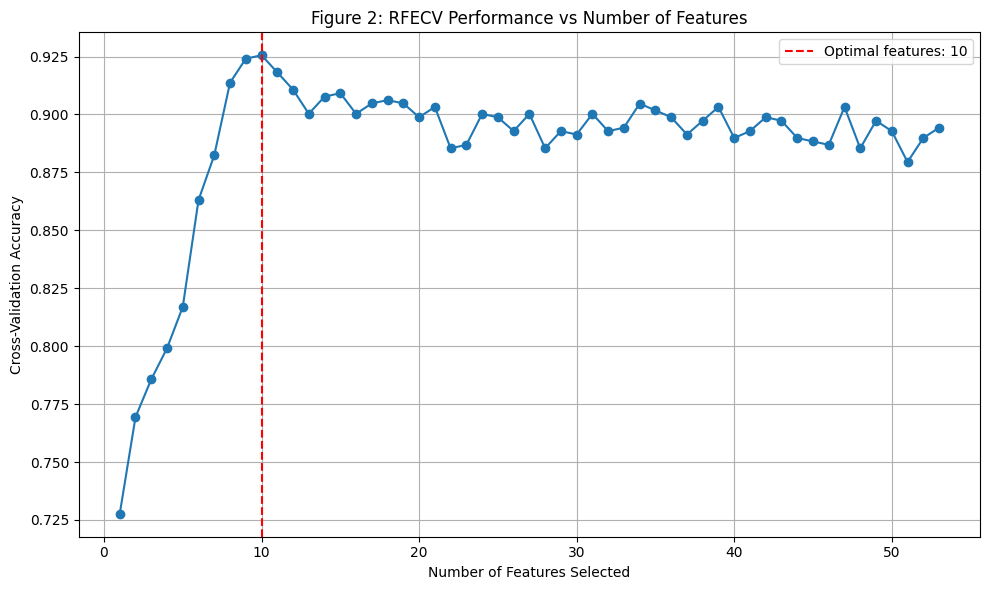

Train size: 537, Test size: 135
Hyperparameter spaces defined.
Stage 1 meta-features shapes: (537, 3) (135, 3)
Stage 2 meta-features shapes: (537, 2) (135, 2)

            DDNet MODEL PERFORMANCE
Accuracy:      99.2593%
Precision:     98.1132%
Recall:        100.0000%
F1-Score:      99.0476%
Log Loss:      0.0173
AUC:           1.0000
Cohen's Kappa: 0.9844


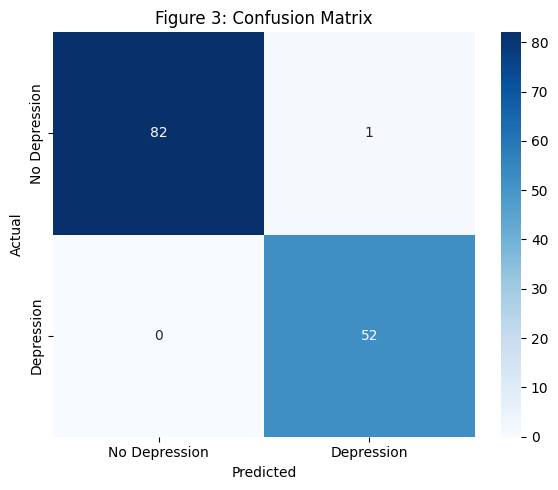

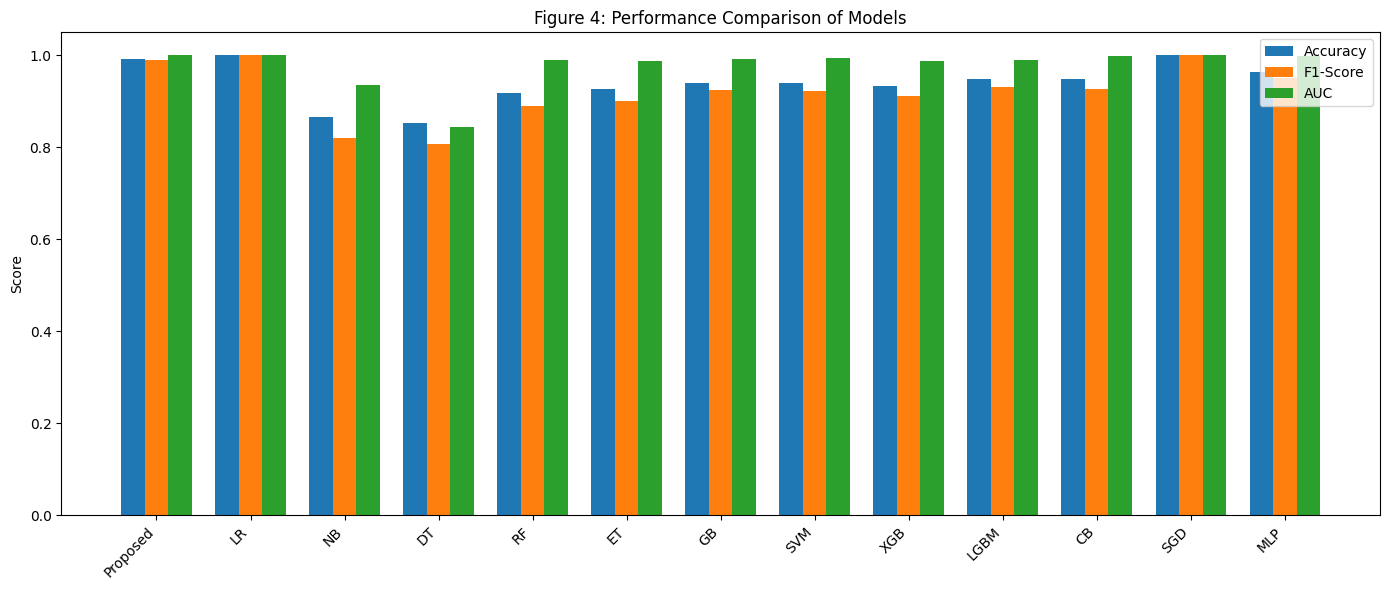


=== Running Paired t-test (10 iterations) ===

=== Paired t-test Results (p-value < 0.05 indicates significant improvement) ===
Proposed vs LR: t-stat=-1.9640, p-value=0.0811
Proposed vs NB: t-stat=9.5886, p-value=0.0000
Proposed vs DT: t-stat=21.6869, p-value=0.0000
Proposed vs RF: t-stat=14.1818, p-value=0.0000
Proposed vs ET: t-stat=13.1157, p-value=0.0000
Proposed vs GB: t-stat=15.4935, p-value=0.0000
Proposed vs SVM: t-stat=6.4137, p-value=0.0001
Proposed vs XGB: t-stat=12.0676, p-value=0.0000
Proposed vs LGBM: t-stat=8.5456, p-value=0.0000
Proposed vs CB: t-stat=11.0000, p-value=0.0000
Proposed vs SGD: t-stat=-1.9640, p-value=0.0811
Proposed vs MLP: t-stat=1.0000, p-value=0.3434

Mean Accuracies over 10 iterations:
Proposed: 0.9978
LR: 1.0000
NB: 0.8756
DT: 0.8644
RF: 0.9207
ET: 0.9119
GB: 0.9452
SVM: 0.9548
XGB: 0.9400
LGBM: 0.9541
CB: 0.9489
SGD: 1.0000
MLP: 0.9948


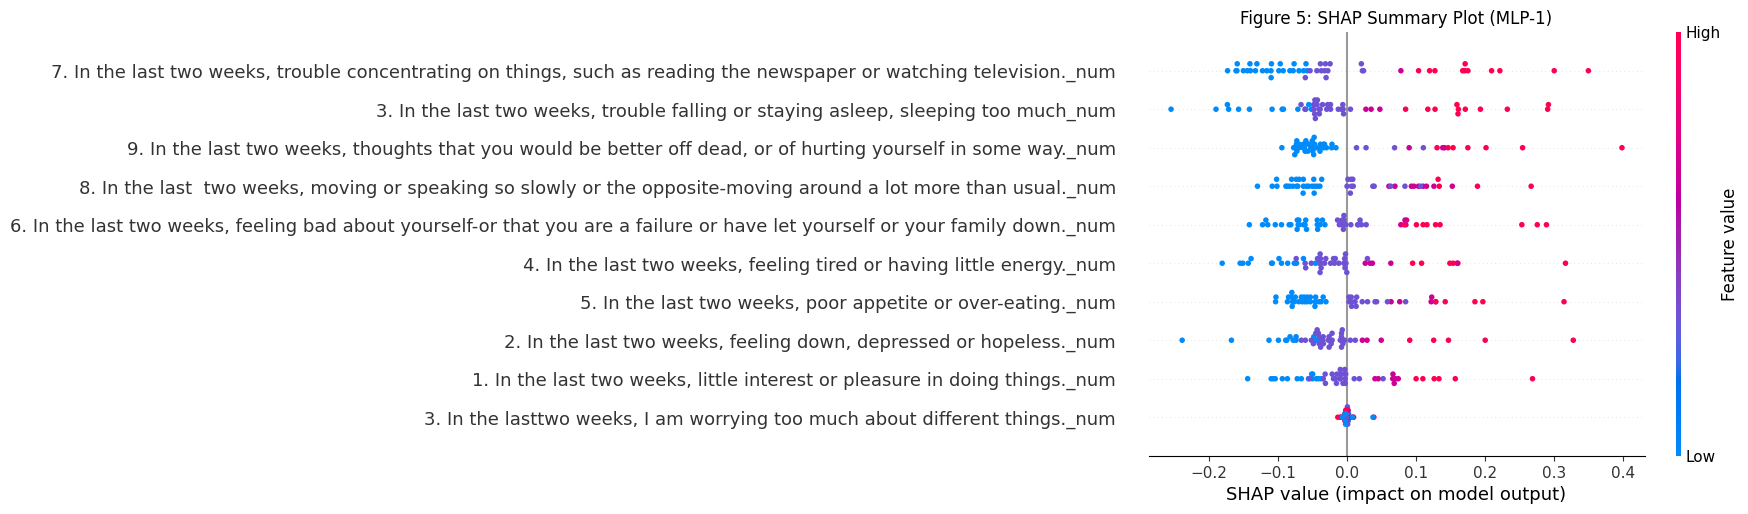

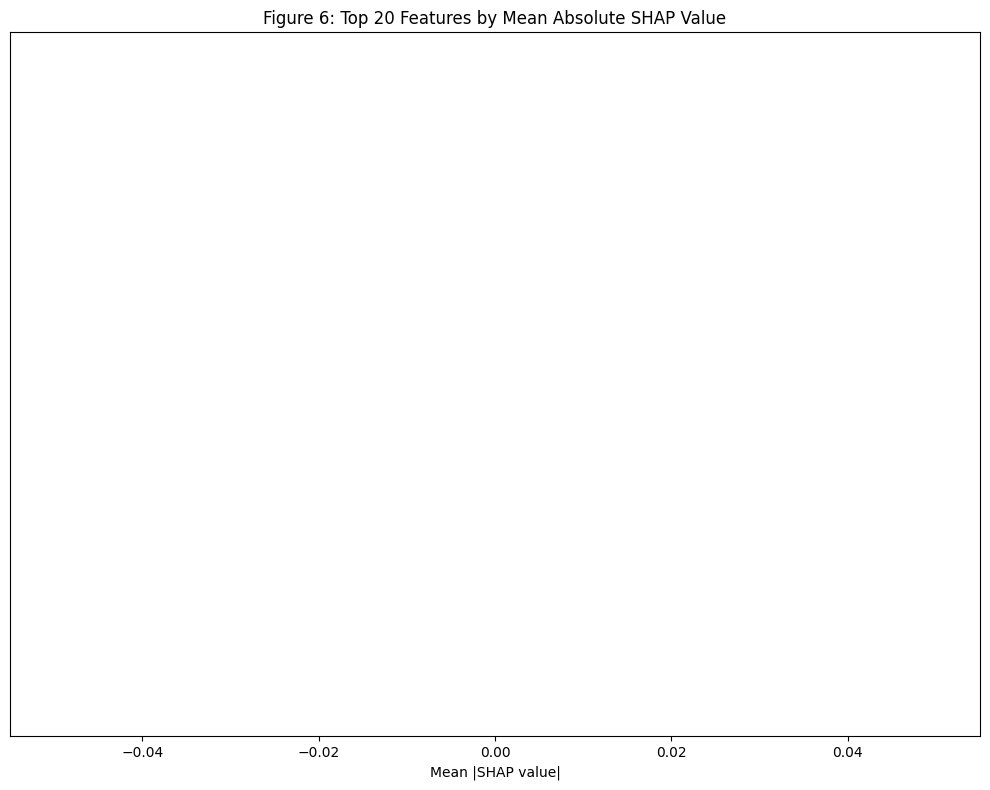

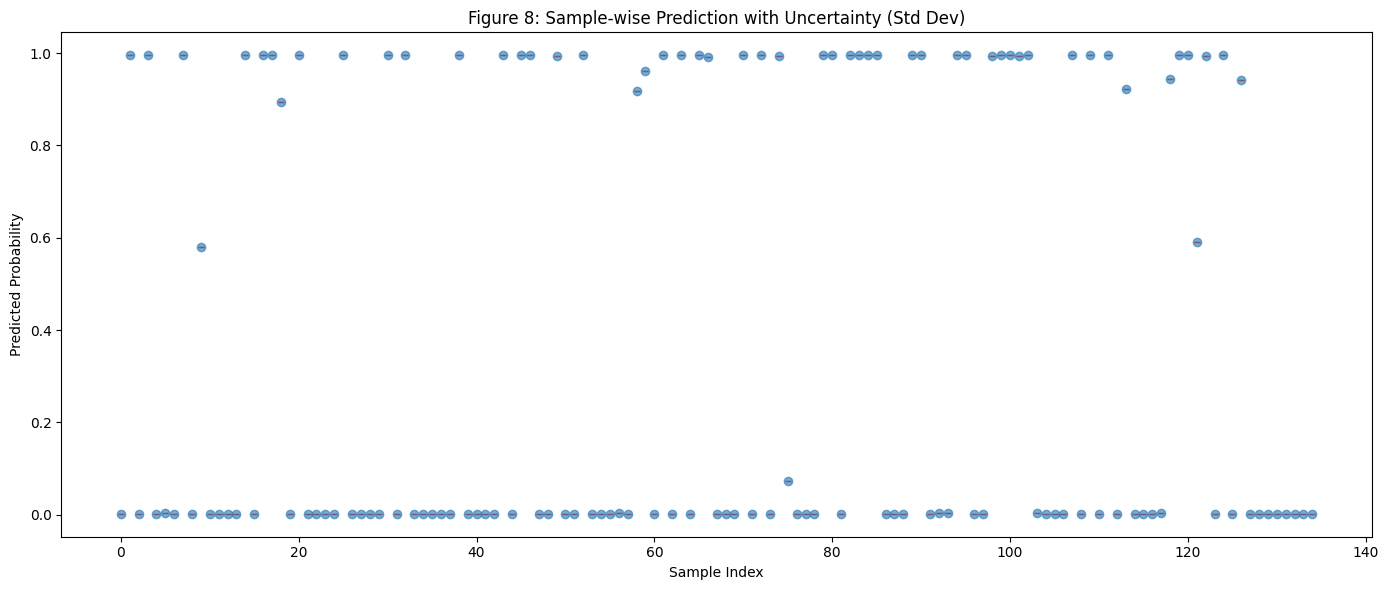

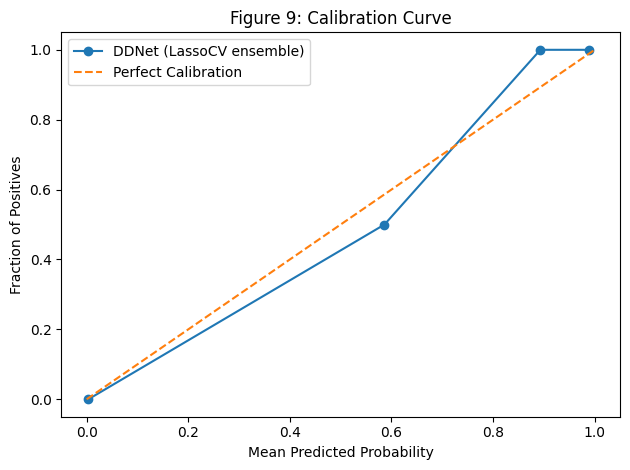

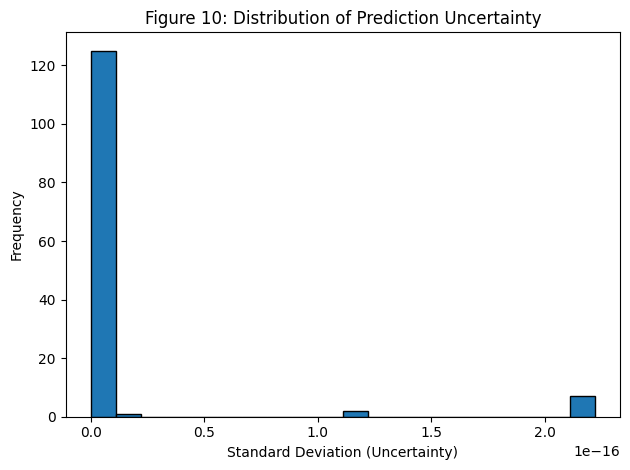

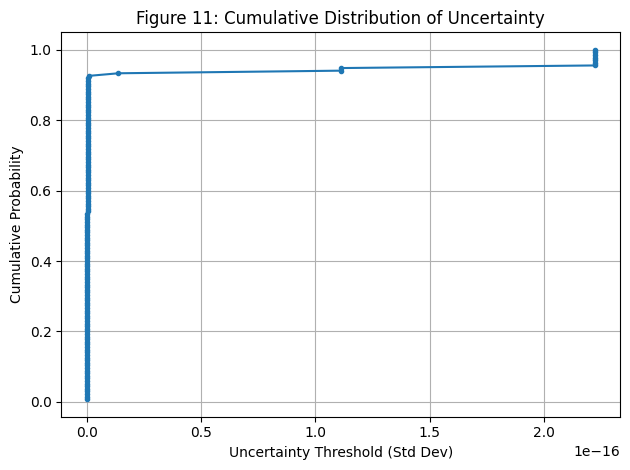


All figures have been saved as PNG files.
Pipeline completed successfully.


In [ ]:
# =============================================================================
# DDNet: Full Implementation with Paired t-test & 11 Figures
# Based on: "DDNet: A Robust and Reliable Hybrid Machine Learning Model..."
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.linear_model import LassoCV, SGDClassifier, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, confusion_matrix, cohen_kappa_score)
from sklearn.base import clone
from sklearn.calibration import calibration_curve

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
from scipy import stats

SEED = 42
np.random.seed(SEED)

# =============================================================================
# 1. Load Dataset and Create Target (PHQ-9 >= 10)
# =============================================================================
df = pd.read_excel('mmc2.xlsx', sheet_name='Sheet1')
print("Dataset shape:", df.shape)

phq_cols = [
    '1. In the last two weeks, little interest or pleasure in doing things.',
    '2. In the last two weeks, feeling down, depressed or hopeless.',
    '3. In the last two weeks, trouble falling or staying asleep, sleeping too much',
    '4. In the last two weeks, feeling tired or having little energy.',
    '5. In the last two weeks, poor appetite or over-eating.',
    '6. In the last two weeks, feeling bad about yourself-or that you are a failure or have let yourself or your family down.',
    '7. In the last two weeks, trouble concentrating on things, such as reading the newspaper or watching television.',
    '8. In the last  two weeks, moving or speaking so slowly or the opposite-moving around a lot more than usual.',
    '9. In the last two weeks, thoughts that you would be better off dead, or of hurting yourself in some way.'
]

def extract_number(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r'\((\d+)\)', str(text))
    if match:
        return int(match.group(1))
    return np.nan

for col in phq_cols:
    df[col + '_num'] = df[col].apply(extract_number)

df['PHQ_total'] = df[[col + '_num' for col in phq_cols]].sum(axis=1)
df['target'] = (df['PHQ_total'] >= 10).astype(int)
print("Target distribution:\n", df['target'].value_counts())

# =============================================================================
# 2. Feature Extraction and Encoding
# =============================================================================
all_cols = df.columns.tolist()
categorical_cols = []
numeric_response_cols = []

for col in all_cols:
    if col in ['target', 'PHQ_total'] or col.endswith('_num'):
        continue
    if 'Express your consent' in col:
        continue
    first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else ''
    if '(' in str(first_val) and ')' in str(first_val):
        numeric_response_cols.append(col)
    else:
        categorical_cols.append(col)

for col in numeric_response_cols:
    df[col + '_num'] = df[col].apply(extract_number)

feature_cols = []
for col in categorical_cols:
    if col not in ['target', 'PHQ_total']:
        feature_cols.append(col)
for col in numeric_response_cols:
    feature_cols.append(col + '_num')

X = df[feature_cols].copy()
y = df['target'].copy()

for col in categorical_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(0)
print("Feature matrix shape:", X.shape)

# =============================================================================
# 3. Scaling
# =============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# =============================================================================
# 4. Feature Selection (Figures 1 & 2)
# =============================================================================
# ANOVA F-test (Figure 1)
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled_df, y)
f_values = pd.Series(selector.scores_, index=X.columns)
f_values.sort_values(ascending=False, inplace=True)
print("Top 15 features by F-value:\n", f_values.head(15))

plt.figure(figsize=(12,8))
f_values.head(20).plot(kind='barh')
plt.title('Figure 1: Top 20 Features by ANOVA F-value')
plt.xlabel('F-value')
plt.tight_layout()
plt.savefig('figure1_anova_fvalues.png', dpi=300)
plt.show()

# RFECV (Figure 2)
rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
rfecv = RFECV(estimator=rf, step=1, cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1)
rfecv.fit(X_scaled_df, y)
optimal_features = X_scaled_df.columns[rfecv.support_]
print(f"Optimal number of features selected: {rfecv.n_features_}")
print("Selected features:", list(optimal_features))

plt.figure(figsize=(10,6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score'])+1),
         rfecv.cv_results_['mean_test_score'], marker='o')
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--',
            label=f'Optimal features: {rfecv.n_features_}')
plt.xlabel('Number of Features Selected')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Figure 2: RFECV Performance vs Number of Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figure2_rfecv.png', dpi=300)
plt.show()

X_selected = X_scaled_df[optimal_features]

# =============================================================================
# 5. Train/Test Split
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# =============================================================================
# 6. Hyperparameter Search Spaces (Random Search)
# =============================================================================
mlp1_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp1_random = list(ParameterSampler(mlp1_param, n_iter=5, random_state=SEED))

mlp2_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp2_random = list(ParameterSampler(mlp2_param, n_iter=5, random_state=SEED))

sgd_param = {
    'max_iter': [1000, 2000],
    'tol': [1e-4, 1e-3],
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'random_state': [SEED]
}
sgd_random = list(ParameterSampler(sgd_param, n_iter=5, random_state=SEED))

cat_param = {
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'verbose': [0],
    'random_state': [SEED]
}
cat_random = list(ParameterSampler(cat_param, n_iter=5, random_state=SEED))

mlp3_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp3_random = list(ParameterSampler(mlp3_param, n_iter=5, random_state=SEED))

print("Hyperparameter spaces defined.")

# =============================================================================
# 7. Helper: Stacked Meta-feature Generator (5-fold CV)
# =============================================================================
def get_meta_features(models, X_train, y_train, X_test, cv=5):
    n_models = len(models)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    meta_train = np.zeros((X_train.shape[0], n_models))
    meta_test = np.zeros((X_test.shape[0], n_models))

    for i, (name, model) in enumerate(models):
        oof_preds = np.zeros(X_train.shape[0])
        test_preds = np.zeros(X_test.shape[0])

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            oof_preds[val_idx] = model_clone.predict_proba(X_val)[:, 1]
            test_preds += model_clone.predict_proba(X_test)[:, 1] / cv

        meta_train[:, i] = oof_preds
        meta_test[:, i] = test_preds

    return meta_train, meta_test

# =============================================================================
# 8. Stage 1: Base Classifiers (MLP-1, MLP-2, SGD)
# =============================================================================
mlp1 = MLPClassifier(**mlp1_random[0])
mlp2 = MLPClassifier(**mlp2_random[0])
sgd = SGDClassifier(**sgd_random[0])

stage1_models = [('MLP1', mlp1), ('MLP2', mlp2), ('SGD', sgd)]
meta_train1, meta_test1 = get_meta_features(
    stage1_models, X_train_np, y_train_np, X_test_np, cv=5
)
print("Stage 1 meta-features shapes:", meta_train1.shape, meta_test1.shape)

# =============================================================================
# 9. Stage 2: Secondary Classifiers (MLP-3, CatBoost)
# =============================================================================
mlp3 = MLPClassifier(**mlp3_random[0])
cat = CatBoostClassifier(**cat_random[0])

stage2_models = [('MLP3', mlp3), ('CatBoost', cat)]
meta_train2, meta_test2 = get_meta_features(
    stage2_models, meta_train1, y_train_np, meta_test1, cv=5
)
print("Stage 2 meta-features shapes:", meta_train2.shape, meta_test2.shape)

# =============================================================================
# 10. Stage 3: Meta-Classifier (LassoCV)
# =============================================================================
lasso = LassoCV(cv=5, alphas=[0.1, 0.01, 0.001], max_iter=1000, random_state=SEED)
lasso.fit(meta_train2, y_train_np)

y_pred_prob = lasso.predict(meta_test2)
y_pred = np.round(y_pred_prob).astype(int)

# =============================================================================
# 11. Evaluation Metrics (Table 2)
# =============================================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
kappa = cohen_kappa_score(y_test, y_pred)

print("\n" + "="*60)
print("            DDNet MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy:      {acc:.4%}")
print(f"Precision:     {prec:.4%}")
print(f"Recall:        {rec:.4%}")
print(f"F1-Score:      {f1:.4%}")
print(f"Log Loss:      {logloss:.4f}")
print(f"AUC:           {auc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print("="*60)

# Figure 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Figure 3: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('figure3_confusion_matrix.png', dpi=300)
plt.show()

# =============================================================================
# 12. Comparison with Other ML Models & Paired t-test (Figure 4)
# =============================================================================
other_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=SEED),
    'NB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=SEED),
    'RF': RandomForestClassifier(random_state=SEED),
    'ET': ExtraTreesClassifier(random_state=SEED),
    'GB': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'XGB': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    'LGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CB': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_state=SEED),
    'SGD': SGDClassifier(loss='log_loss', max_iter=1000, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=SEED)
}

# Evaluate on current test set for Figure 4
other_acc = {}
other_f1 = {}
other_auc = {}
for name, model in other_models.items():
    model_clone = clone(model)
    model_clone.fit(X_train_np, y_train_np)
    y_pred_other = model_clone.predict(X_test_np)
    y_prob_other = model_clone.predict_proba(X_test_np)[:, 1]
    other_acc[name] = accuracy_score(y_test_np, y_pred_other)
    other_f1[name] = f1_score(y_test_np, y_pred_other)
    other_auc[name] = roc_auc_score(y_test_np, y_prob_other)

# Figure 4: Performance comparison bar chart
models_list = ['Proposed'] + list(other_models.keys())
acc_vals = [acc] + [other_acc[name] for name in other_models.keys()]
f1_vals = [f1] + [other_f1[name] for name in other_models.keys()]
auc_vals = [auc] + [other_auc[name] for name in other_models.keys()]

fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(models_list))
width = 0.25
ax.bar(x - width, acc_vals, width, label='Accuracy')
ax.bar(x, f1_vals, width, label='F1-Score')
ax.bar(x + width, auc_vals, width, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Figure 4: Performance Comparison of Models')
ax.legend()
plt.tight_layout()
plt.savefig('figure4_model_comparison.png', dpi=300)
plt.show()

# Paired t-test (10 iterations)
print("\n=== Running Paired t-test (10 iterations) ===")
n_iter = 10
acc_proposed = []
acc_others = {name: [] for name in other_models}

for i in range(n_iter):
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X_selected, y, test_size=0.2, random_state=i*10+SEED, stratify=y
    )
    X_train_np_i = X_train_i.values
    X_test_np_i = X_test_i.values
    y_train_np_i = y_train_i.values
    y_test_np_i = y_test_i.values

    # Proposed stacking
    meta_train1_i, meta_test1_i = get_meta_features(
        stage1_models, X_train_np_i, y_train_np_i, X_test_np_i, cv=5
    )
    meta_train2_i, meta_test2_i = get_meta_features(
        stage2_models, meta_train1_i, y_train_np_i, meta_test1_i, cv=5
    )
    lasso_i = LassoCV(cv=5, alphas=[0.1, 0.01, 0.001], max_iter=1000, random_state=SEED)
    lasso_i.fit(meta_train2_i, y_train_np_i)
    y_pred_i = np.round(lasso_i.predict(meta_test2_i)).astype(int)
    acc_proposed.append(accuracy_score(y_test_np_i, y_pred_i))

    # Other models
    for name, model in other_models.items():
        model_clone = clone(model)
        model_clone.fit(X_train_np_i, y_train_np_i)
        y_pred_other = model_clone.predict(X_test_np_i)
        acc_others[name].append(accuracy_score(y_test_np_i, y_pred_other))

print("\n=== Paired t-test Results (p-value < 0.05 indicates significant improvement) ===")
for name in other_models:
    t_stat, p_val = stats.ttest_rel(acc_proposed, acc_others[name])
    print(f"Proposed vs {name}: t-stat={t_stat:.4f}, p-value={p_val:.4f}")

print("\nMean Accuracies over 10 iterations:")
print(f"Proposed: {np.mean(acc_proposed):.4f}")
for name in other_models:
    print(f"{name}: {np.mean(acc_others[name]):.4f}")

# =============================================================================
# 13. Explainable AI (SHAP) - Figures 5, 6, 7
# =============================================================================
# Retrain MLP-1 on full training set
mlp1_final = clone(mlp1)
mlp1_final.fit(X_train_np, y_train_np)

background = X_train_np[np.random.choice(X_train_np.shape[0], 100, replace=False)]
X_test_subset = X_test_np[:50]
feature_names = X_train.columns.tolist()

explainer = shap.Explainer(mlp1_final.predict_proba, background)
shap_values = explainer(X_test_subset)          # shape: (50, n_features, 2)
shap_values_class1 = shap_values[:, :, 1]       # class 1

# Figure 5: SHAP summary plot
shap.summary_plot(shap_values_class1, X_test_subset, feature_names=feature_names, show=False)
plt.title('Figure 5: SHAP Summary Plot (MLP-1)')
plt.tight_layout()
plt.savefig('figure5_shap_summary.png', dpi=300)
plt.show()

# Figure 6: SHAP bar plot
mean_abs_shap = np.mean(np.abs(shap_values_class1), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1][:20]
plt.figure(figsize=(10,8))
plt.barh(np.array(feature_names)[sorted_idx], mean_abs_shap[sorted_idx])
plt.xlabel('Mean |SHAP value|')
plt.title('Figure 6: Top 20 Features by Mean Absolute SHAP Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figure6_shap_bar.png', dpi=300)
plt.show()

# Figure 7: SHAP force plot for the first sample
# Use the Explanation object directly (no need to extract base_value)
fig_force = shap.plots.force(shap_values[0, :, 1], matplotlib=True, show=False)
fig_force.savefig('figure7_shap_force.png', dpi=300)
plt.close(fig_force)

# =============================================================================
# 14. Uncertainty Analysis - Figures 8, 9, 10, 11
# =============================================================================
n_iter_unc = 10
predictions_unc = []
for seed in range(n_iter_unc):
    lasso_unc = LassoCV(cv=5, alphas=[0.1, 0.01, 0.001], max_iter=1000, random_state=seed)
    lasso_unc.fit(meta_train2, y_train_np)
    predictions_unc.append(lasso_unc.predict(meta_test2))

predictions_unc = np.array(predictions_unc)
mean_pred_unc = np.mean(predictions_unc, axis=0)
std_pred_unc = np.std(predictions_unc, axis=0)

# Figure 8: Sample-wise uncertainty plot
plt.figure(figsize=(14,6))
plt.errorbar(range(len(mean_pred_unc)), mean_pred_unc, yerr=std_pred_unc,
             fmt='o', alpha=0.6, ecolor='red', capsize=2)
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.title('Figure 8: Sample-wise Prediction with Uncertainty (Std Dev)')
plt.tight_layout()
plt.savefig('figure8_uncertainty_samples.png', dpi=300)
plt.show()

# Figure 9: Calibration curve
prob_true, prob_pred_cal = calibration_curve(y_test, mean_pred_unc, n_bins=10)
plt.figure()
plt.plot(prob_pred_cal, prob_true, marker='o', label='DDNet (LassoCV ensemble)')
plt.plot([0, 1], [0, 1], '--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Figure 9: Calibration Curve')
plt.tight_layout()
plt.savefig('figure9_calibration.png', dpi=300)
plt.show()

# Figure 10: Histogram of uncertainty
plt.figure()
plt.hist(std_pred_unc, bins=20, edgecolor='black')
plt.xlabel('Standard Deviation (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Figure 10: Distribution of Prediction Uncertainty')
plt.tight_layout()
plt.savefig('figure10_uncertainty_histogram.png', dpi=300)
plt.show()

# Figure 11: Cumulative probability of uncertainty
sorted_std = np.sort(std_pred_unc)
cum_prob = np.arange(1, len(sorted_std)+1) / len(sorted_std)
plt.figure()
plt.plot(sorted_std, cum_prob, marker='.')
plt.xlabel('Uncertainty Threshold (Std Dev)')
plt.ylabel('Cumulative Probability')
plt.title('Figure 11: Cumulative Distribution of Uncertainty')
plt.grid(True)
plt.tight_layout()
plt.savefig('figure11_cumulative_uncertainty.png', dpi=300)
plt.show()

print("\nAll figures have been saved as PNG files.")
print("Pipeline completed successfully.")